In [9]:
import pandas as pd

df_evaluations_all=pd.read_json("./evaluations/evaluations_results_pipeline_QS2.json")
print("DF shape;", df_evaluations_all.shape)
print("Corpus évalués:", df_evaluations_all["corpus"].unique())

df_evaluations=df_evaluations_all[df_evaluations_all["corpus"]=='L-IA-notre-deuxieme-conscience'].copy()

used_judges=[el.split("_")[-1] for el in df_evaluations.columns if "custom_evaluation_text" in el]
print("used_judges:\n", used_judges)

models_ratio_scores=[]
for judge in used_judges:
    label_metric=f"{judge}_ratio_score"
    score=round(df_evaluations[f"score_B (RAG)_{judge}"]/df_evaluations[f"score_A (réf.)_{judge}"], 2)    
    if score.any():
        df_evaluations[label_metric]=score
        models_ratio_scores.append(label_metric)




display(df_evaluations.drop(columns=[
    "corpus", "question", "date", 'dataset', "difficulte", 'source',
    "reponse_reference", "response",
    "custom_evaluation_text_gpt-5.2", "custom_evaluation_text_gpt-5-mini", "custom_evaluation_text_gemini-3-flash-preview",
    # "custom_evaluation_text_gemini-3.1-pro-preview"
    # 'score_A (réf.)_gemini-3.1-pro-preview', 'score_B (RAG)_gemini-3.1-pro-preview', 
     'score_A (réf.)_gemini-3-flash-preview', 'score_B (RAG)_gemini-3-flash-preview', 
     'score_A (réf.)_gpt-5.2', 'score_B (RAG)_gpt-5.2', 
    'score_A (réf.)_gpt-5-mini', 'score_B (RAG)_gpt-5-mini',    

]))

print("\n===Gap scores group by model et rag type:===\n")
for s in models_ratio_scores:    
    print(s)
    display(df_evaluations.groupby(["model", 'rag_type'])[s].mean().reset_index())



DF shape; (148, 24)
Corpus évalués: ['La-France-est-elle-reformable' 'L-IA-notre-deuxieme-conscience']
used_judges:
 ['gemini-3.1-pro-preview', 'gpt-5.2', 'gemini-3-flash-preview', 'gpt-5-mini']


,type,rag_type,model,score_A (réf.)_gemini-3.1-pro-preview,score_B (RAG)_gemini-3.1-pro-preview,custom_evaluation_text_gemini-3.1-pro-preview,difficulty,gemini-3.1-pro-preview_ratio_score,gpt-5.2_ratio_score,gemini-3-flash-preview_ratio_score,gpt-5-mini_ratio_score
108,NEEDLE,hybrid,Qwen3-235B-A22B-Instruct-2507:novita,10,10,"{'score_A': 10, 'score_B': 10, 'meilleure_repo...",basique,1.00,1.14,1.11,1.29
109,NEEDLE,hybrid,Qwen3-235B-A22B-Instruct-2507:novita,10,10,"{'score_A': 10, 'score_B': 10, 'meilleure_repo...",basique,1.00,1.00,1.00,1.11
110,NEEDLE,hybrid,Qwen3-235B-A22B-Instruct-2507:novita,10,10,"{'score_A': 10, 'score_B': 10, 'meilleure_repo...",basique,1.00,1.00,1.11,1.25
111,NEEDLE,hybrid,Qwen3-235B-A22B-Instruct-2507:novita,10,10,"{'score_A': 10, 'score_B': 10, 'meilleure_repo...",intermédiaire,1.00,1.11,1.00,1.11
112,MULTI_HOP,hybrid,Qwen3-235B-A22B-Instruct-2507:novita,9,10,"{'score_A': 9, 'score_B': 10, 'meilleure_repon...",expert,1.11,1.12,1.25,1.29
113,MULTI_HOP,hybrid,Qwen3-235B-A22B-Instruct-2507:novita,10,10,"{'score_A': 10, 'score_B': 10, 'meilleure_repo...",expert,1.00,1.12,1.25,1.29
114,MULTI_HOP,hybrid,Qwen3-235B-A22B-Instruct-2507:novita,9,10,"{'score_A': 9, 'score_B': 10, 'meilleure_repon...",intermédiaire,1.11,1.12,1.25,1.29
115,MULTI_HOP,hybrid,Qwen3-235B-A22B-Instruct-2507:novita,9,10,"{'score_A': 9, 'score_B': 10, 'meilleure_repon...",intermédiaire,1.11,1.12,1.25,1.29
116,QUOTE_EXPLANATION,hybrid,Qwen3-235B-A22B-Instruct-2507:novita,9,10,"{'score_A': 9, 'score_B': 10, 'meilleure_repon...",intermédiaire,1.11,1.00,1.25,1.29
117,QUOTE_EXPLANATION,hybrid,Qwen3-235B-A22B-Instruct-2507:novita,10,10,"{'score_A': 10, 'score_B': 10, 'meilleure_repo...",expert,1.00,1.00,1.11,1.29



===Gap scores group by model et rag type:===

gemini-3.1-pro-preview_ratio_score


,model,rag_type,gemini-3.1-pro-preview_ratio_score
0,Qwen3-235B-A22B-Instruct-2507:novita,hybrid,1.0285
1,Qwen3-235B-A22B-Instruct-2507:novita,hybrid_hyde,1.0335


gpt-5.2_ratio_score


,model,rag_type,gpt-5.2_ratio_score
0,Qwen3-235B-A22B-Instruct-2507:novita,hybrid,1.0430
1,Qwen3-235B-A22B-Instruct-2507:novita,hybrid_hyde,1.0325


gemini-3-flash-preview_ratio_score


,model,rag_type,gemini-3-flash-preview_ratio_score
0,Qwen3-235B-A22B-Instruct-2507:novita,hybrid,1.1440
1,Qwen3-235B-A22B-Instruct-2507:novita,hybrid_hyde,1.1245


gpt-5-mini_ratio_score


,model,rag_type,gpt-5-mini_ratio_score
0,Qwen3-235B-A22B-Instruct-2507:novita,hybrid,1.2175
1,Qwen3-235B-A22B-Instruct-2507:novita,hybrid_hyde,1.2560


In [6]:
# inspecter une question
from IPython.display import Markdown
i=146
question=df_evaluations.loc[i, "question"]
resp=df_evaluations.loc[i, "response"]
ref=df_evaluations.loc[i, "reponse_reference"]
verdict=df_evaluations.loc[i, 'custom_evaluation_text_gemini-3.1-pro-preview']

print("\n=====\nQuestion:", question)

print("\n=====\nRéponse:")
display(Markdown(resp))

print("\n----\nReference:", ref)

display(Markdown(ref))

print(verdict)


=====
Question: Pour quelle raison Daniel Andler et Laurence Devillers s'accordent-ils à dire que l'intelligence artificielle n'a encore aucune utilité dans nos tâches quotidiennes ?

=====
Réponse:


**Question :**  
Pour quelle raison Daniel Andler et Laurence Devillers s'accordent-ils à dire que l'intelligence artificielle n'a encore aucune utilité dans nos tâches quotidiennes ?

---

**Raisonnement :**  
Le corpus distillé indique que Daniel Andler et Laurence Devillers ne partagent **pas** la même position sur l’utilité quotidienne de l’intelligence artificielle : au contraire, ils sont en **désaccord marqué** sur ce point (cf. D1 dans la section *Désaccords*). Daniel Andler affirme que l’IA n’est que rarement utile dans les situations quotidiennes, tandis que Laurence Devillers soutient que l’IA est déjà omniprésente et profondément intégrée à notre vie quotidienne. La question suppose donc une convergence qui, selon les documents, **n’existe pas**.

Les fragments de retrieval confirment ce désaccord :
- Daniel Andler (dans les fragments ID: 9adf426bd44d817e44d4e3df4d2d5c8c, ID: 4f48a0f736ff79db227fcf6d9d3635c2, ID: 482d3b579039151a4483c62822191afa) insiste sur la rareté des situations où l’IA intervient utilement dans la journée type d’un individu. Il reconnaît son utilité dans des tâches précises (écriture de code, traduction), mais nie qu’elle soit omniprésente ou fondamentalement utile dans la plupart des situations.
- Laurence Devillers (dans les ID: ec835f8deee5523f89af7a195a34c544, ec74aa1e6fba9ceeddd3009257a8a3e1, 61e7eaa75659bcc1ecc71cc9e6728f35) affirme le contraire : l’IA est déjà très présente, notamment dans les interactions conversationnelles, la reconnaissance vocale, et les systèmes qui exploitent nos pulsions. Elle met en garde contre son usage manipulatoire et son impact sur l’isolement social.

Il n’y a donc **aucune convergence** entre les deux auteurs sur l’utilité quotidienne de l’IA. La question repose sur une **hypothèse erronée**.

---

**Réponse :**  
Daniel Andler et Laurence Devillers **ne s'accordent pas** sur le fait que l’intelligence artificielle n’ait aucune utilité dans nos tâches quotidiennes. Au contraire, ils expriment des positions **opposées** sur ce point.

Daniel Andler estime que l’IA a une utilité **limitée** dans la vie quotidienne. Il reconnaît qu’elle peut aider à résoudre certains problèmes ponctuels, comme écrire une ligne de code ou traduire une langue inconnue en 10 minutes, mais affirme que, dans la plupart des situations entre le réveil et l’endormissement, l’IA n’a rien à apporter. Pour lui, le remplacement de l’humain par l’IA est un mythe, illustré par le fait que, malgré les prédictions, il n’y a jamais eu autant de postes de radiologues (C12).

En revanche, Laurence Devillers affirme que l’IA est **déjà omniprésente** dans nos vies quotidiennes. Elle souligne que les discours sur la "super-intelligence" sont des récits marketing (C25), mais insiste sur le fait que les IA conversationnelles sont utilisées comme interlocuteurs intimes, voire comme substituts aux relations humaines. Elle voit dans cette anthropomorphisation un danger social majeur, car elle conduit à l’isolement et à une manipulation comportementale (C35, C30). Pour elle, l’IA n’est pas une simple absence d’utilité, mais une **présence active et intrusive**.

Ainsi, loin de converger, leurs positions s’opposent : Andler minimise l’impact quotidien de l’IA, tandis que Devillers l’agrandit et l’alarme.

---

**Sources :**  
- ID: 9adf426bd44d817e44d4e3df4d2d5c8c  
- ID: 4f48a0f736ff79db227fcf6d9d3635c2  
- ID: 482d3b579039151a4483c62822191afa  
- ID: ec835f8deee5523f89af7a195a34c544  
- ID: ec74aa1e6fba9ceeddd3009257a8a3e1  
- ID: 61e7eaa75659bcc1ecc71cc9e6728f35  
- CORPUS DISTILLÉ (D1 — Désaccords, C11, C12, C14, C15, C25, C35)


----
Reference: Le contexte fourni ne permet pas de répondre à cette question car sa prémisse est fausse : Daniel Andler et Laurence Devillers ne s'accordent pas sur ce point. Si Daniel Andler affirme que l'intelligence artificielle n'a pas ou peu d'utilité dans nos tâches quotidiennes, Laurence Devillers exprime au contraire son désaccord total en soutenant que l'IA est déjà omniprésente et utilisée tous les jours algorithmiquement (reconnaissance faciale et vocale, agents conversationnels).


Le contexte fourni ne permet pas de répondre à cette question car sa prémisse est fausse : Daniel Andler et Laurence Devillers ne s'accordent pas sur ce point. Si Daniel Andler affirme que l'intelligence artificielle n'a pas ou peu d'utilité dans nos tâches quotidiennes, Laurence Devillers exprime au contraire son désaccord total en soutenant que l'IA est déjà omniprésente et utilisée tous les jours algorithmiquement (reconnaissance faciale et vocale, agents conversationnels).

{'score_A': 10, 'score_B': 10, 'meilleure_reponse': 'B', 'evaluation': {'verdict': 'Les deux réponses identifient parfaitement la fausse prémisse, mais la réponse B offre une explication beaucoup plus détaillée et sourcée des positions respectives des deux auteurs.', 'points_cles': {'communs': ["Détection de la fausse prémisse : les auteurs ne sont pas d'accord.", "Position de Daniel Andler : l'IA a peu ou pas d'utilité dans le quotidien.", "Position de Laurence Devillers : l'IA est déjà omniprésente au quotidien."], 'specifiques_A': ['Réponse très concise allant droit au but.'], 'specifiques_B': ['Explicite le raisonnement interne.', "Mentionne des exemples concrets pour la position d'Andler (écriture de code, traduction, mythe du remplacement des radiologues).", 'Détaille les craintes de Devillers (anthropomorphisation, isolement, IA comme interlocuteur intime).', 'Cite explicitement les identifiants de sources et fragments.']}, 'analyse_A': {'qualite': 'Excellente détection de la fa

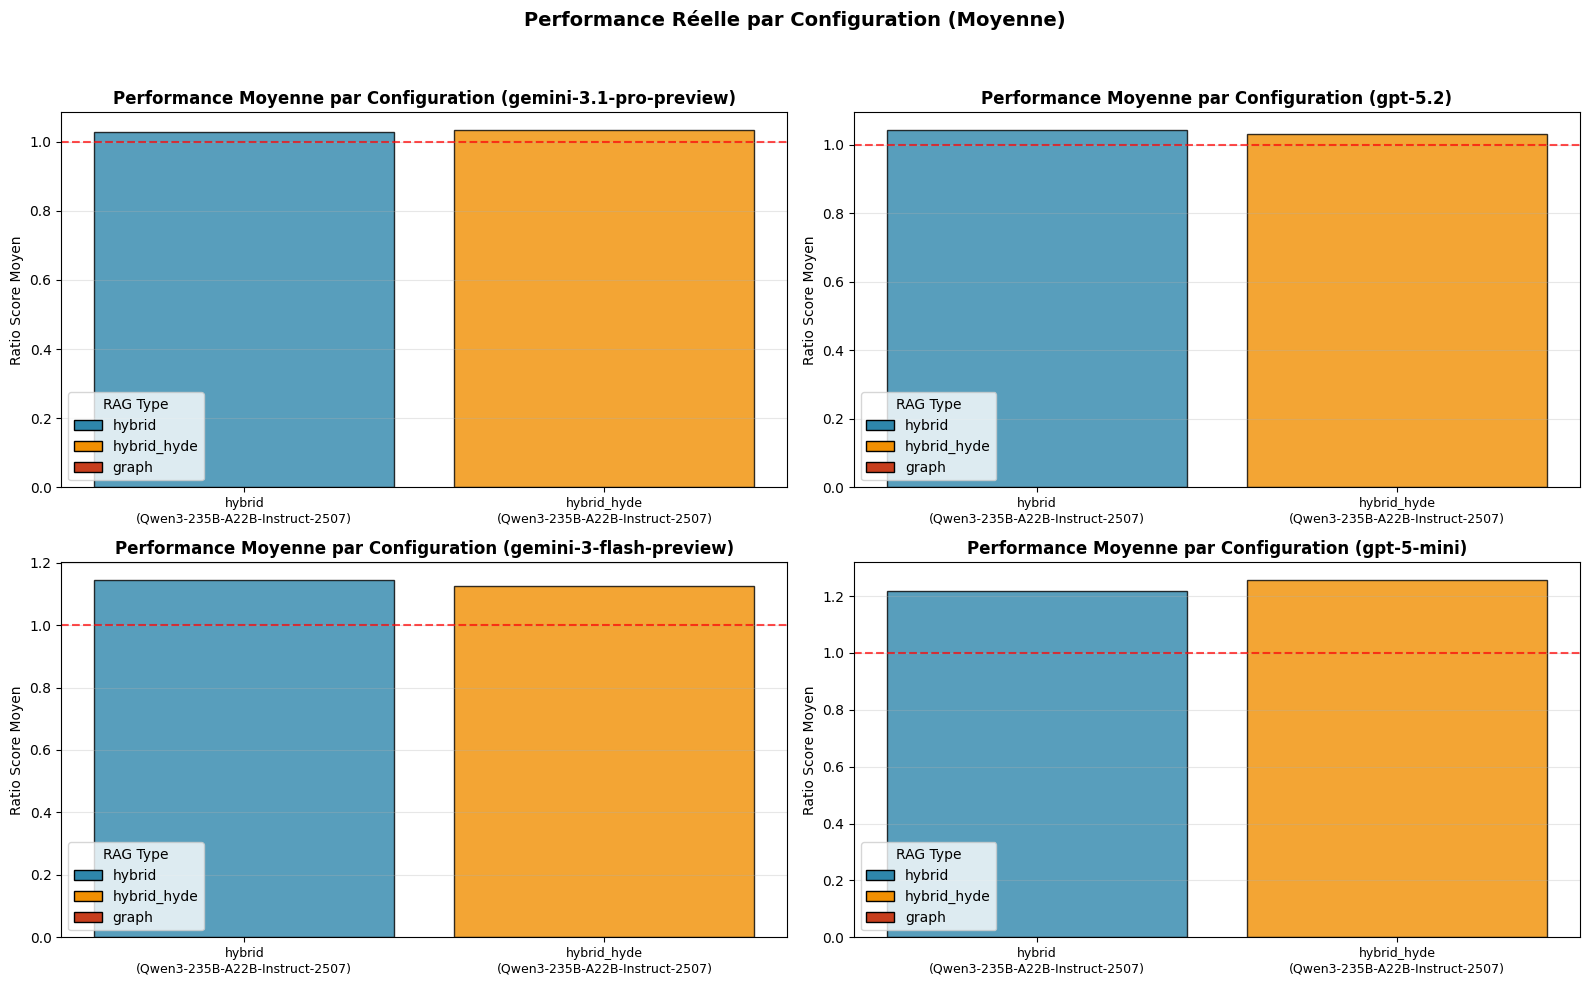

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_viz = df_evaluations.copy()
df_viz['model_short'] = df_viz['model'].str.split(':').str[0]

# Calcul des moyennes
models_ratio_means=[
    {
        "label": m.split("_r")[0],
        "stats": df_viz.groupby(['model_short', 'rag_type'])[m].mean().reset_index()
    }
    for m in models_ratio_scores
]

# Correction 1: figsize plus grand pour 4 graphiques
# Correction 2: flatten() pour accéder aux axes en 1D
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

models = df_viz['model_short'].unique()
colors = {'hybrid': '#2E86AB', 'hybrid_hyde': '#F18F01', 'graph': '#C73E1D'}

axes_stats_models=[]
for axe, stats_model in zip(axes, models_ratio_means):
    print
    axes_stats_models.append((axe, stats_model["stats"], stats_model["label"]))
    
for ax, data, title in axes_stats_models:    
    x_pos = 0
    width = 0.25
    positions = []
    labels = []
    
    for model in models:
        subset = data[data['model_short'] == model]
        for _, row in subset.iterrows():
            positions.append(x_pos)
            labels.append(f"{row['rag_type']}\n({row['model_short']})")
            ax.bar(x_pos, row.iloc[2], width, 
                   color=colors[row['rag_type']], 
                   edgecolor='black', alpha=0.8)
            x_pos += width + 0.05
        
        x_pos += 0.1
    
    ax.axhline(1.0, color='red', linestyle='--', alpha=0.7)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
    ax.set_ylabel('Ratio Score Moyen', fontsize=10)
    ax.set_title(f'Performance Moyenne par Configuration ({title})', fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=colors[r], edgecolor='black', label=r) 
                       for r in ['hybrid', 'hybrid_hyde', 'graph']]
    ax.legend(handles=legend_elements, title='RAG Type')

plt.suptitle('Performance Réelle par Configuration (Moyenne)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

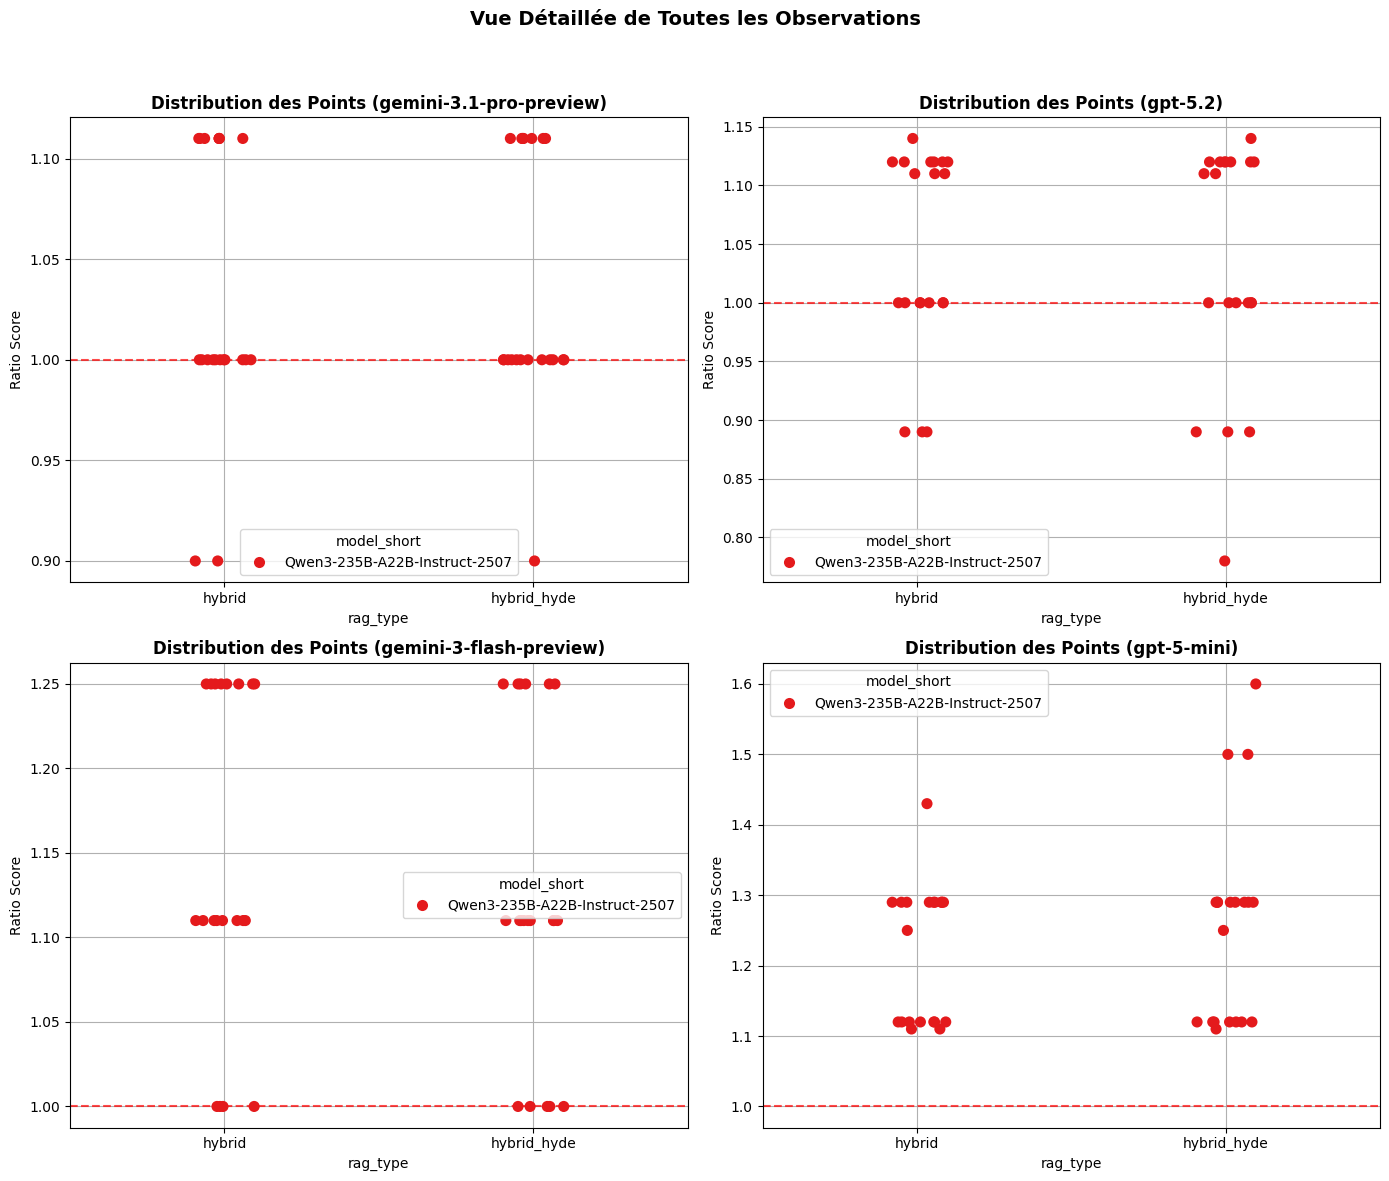

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()  # Correction : convertir en tableau 1D


for axe, model in zip(axes, models_ratio_scores):
    sns.stripplot(data=df_viz, x='rag_type', y=model, 
                hue='model_short', ax=axe, size=8, palette='Set1')
    axe.axhline(1.0, color='red', linestyle='--', alpha=0.7)
    axe.set_title(f'Distribution des Points ({model.split("_r")[0]})', fontweight='bold')
    axe.set_ylabel('Ratio Score')
    axe.grid()

plt.suptitle('Vue Détaillée de Toutes les Observations', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()